# Network Intrusion Detection: Catching Cyber Threats with ML

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Cybersecurity anomaly detection for government and enterprise networks

---

This notebook builds a practical, production-oriented **binary intrusion detection classifier** (normal vs. attack) using machine learning on network connection features. The framing is deliberately enterprise/government — we're thinking about how these models slot into a Security Operations Centre (SOC), integrate with SIEM platforms (Splunk, Sentinel, QRadar), and align with frameworks like the **ASD Essential Eight** and **ACSC ISM** guidelines.

We train and compare four classifiers, then dive deep into threshold tuning, feature importance, and what a production IDS deployment actually looks like.

**Metrics that matter to SOC analysts:** precision (alert fatigue), recall (missed attacks), F1, and ROC-AUC.

**Runtime target:** < 10 minutes on Kaggle free CPU (3-fold CV, capped estimators, no synthetic oversampling).

## 0 · Environment Setup

In [1]:
import os, warnings, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100,
})

C_NORMAL = '#2ecc71'
C_ATTACK = '#e74c3c'
C_PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6',
             '#1abc9c', '#e67e22', '#2c3e50', '#d35400', '#8e44ad']

print("Environment ready ✓")

Environment ready ✓


## 1 · Data Loading & Initial Assessment

> **Kaggle path discovery** — the CSV may not live at the default path.  
> We scan the entire input directory and auto-detect the data file.

In [2]:
# ── Discover and load data (all-in-one) ──
data_path = None
all_files = []

if os.path.exists('/kaggle/input'):
    print("Scanning /kaggle/input ...\n")
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / 1e6
            print(f"  {full}  ({size_mb:.1f} MB)")
            all_files.append(full)

    for ext in ['.csv', '.tsv', '.parquet', '.data', '.txt', '.xlsx', '.json']:
        matches = [f for f in all_files if f.lower().endswith(ext)]
        if matches:
            data_path = max(matches, key=os.path.getsize)
            break
    if data_path is None and all_files:
        data_path = max(all_files, key=os.path.getsize)
else:
    candidates = glob.glob('*.csv') + glob.glob('*.data') + glob.glob('*.tsv')
    if candidates:
        data_path = candidates[0]

if data_path is None:
    raise FileNotFoundError("No data file found in /kaggle/input — did you add the dataset?")

print(f"\n>>> Loading: {data_path}")

ext = os.path.splitext(data_path)[1].lower()
if ext == '.tsv':
    df_raw = pd.read_csv(data_path, sep='\t')
elif ext == '.parquet':
    df_raw = pd.read_parquet(data_path)
elif ext in ['.xlsx', '.xls']:
    df_raw = pd.read_excel(data_path)
else:
    df_raw = pd.read_csv(data_path)

print(f"Shape : {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head()

Scanning /kaggle/input ...

  /kaggle/input/datasets/sampadab17/network-intrusion-detection/Train_data.csv  (2.9 MB)
  /kaggle/input/datasets/sampadab17/network-intrusion-detection/Test_data.csv  (2.4 MB)

>>> Loading: /kaggle/input/datasets/sampadab17/network-intrusion-detection/Train_data.csv
Shape : 25,192 rows  ×  42 columns
Memory: 13.0 MB


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
# Quick schema overview
info_df = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.notnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique()
})
info_df

,dtype,non_null,null_pct,nunique
duration,int64,25192,0.0,758
protocol_type,object,25192,0.0,3
service,object,25192,0.0,66
flag,object,25192,0.0,11
src_bytes,int64,25192,0.0,1665
dst_bytes,int64,25192,0.0,3922
land,int64,25192,0.0,2
wrong_fragment,int64,25192,0.0,3
urgent,int64,25192,0.0,2
hot,int64,25192,0.0,22


In [4]:
# Identify the target column
target_candidates = [c for c in df_raw.columns if c.lower() in
                     ('class', 'label', 'attack_type', 'target', 'attack_cat')]
if target_candidates:
    TARGET = target_candidates[0]
else:
    TARGET = df_raw.columns[-1]

print(f"Target column: '{TARGET}'")
print(f"Unique classes: {df_raw[TARGET].nunique()}")
print()
vc_target = df_raw[TARGET].value_counts()
print(vc_target)

# Detect the "normal" class robustly
normal_keywords = ['normal', 'benign', 'legitimate', 'safe']
NORMAL_CLASS = None
for cls in vc_target.index:
    if any(kw in str(cls).lower() for kw in normal_keywords):
        NORMAL_CLASS = cls
        break
if NORMAL_CLASS is None:
    NORMAL_CLASS = vc_target.index[0]
    print(f"\n⚠ No keyword match — using most frequent class as normal: '{NORMAL_CLASS}'")
else:
    print(f"\n✓ Normal class detected: '{NORMAL_CLASS}'")

IS_BINARY = (df_raw[TARGET].nunique() == 2)
print(f"Binary dataset: {IS_BINARY}")

def is_normal(label):
    return str(label) == str(NORMAL_CLASS)

Target column: 'class'
Unique classes: 2

class
normal     13449
anomaly    11743
Name: count, dtype: int64

✓ Normal class detected: 'normal'
Binary dataset: True


## 2 · Exploratory Data Analysis

Before modelling, a SOC analyst needs to understand the traffic profile:
- **Class balance** — determines alert-fatigue risk and whether we need class weighting
- **Protocol & flag patterns** — which services/protocols carry the most attacks?
- **Feature distributions** — how do normal and malicious connections differ?
- **Correlations** — can we collapse redundant features?

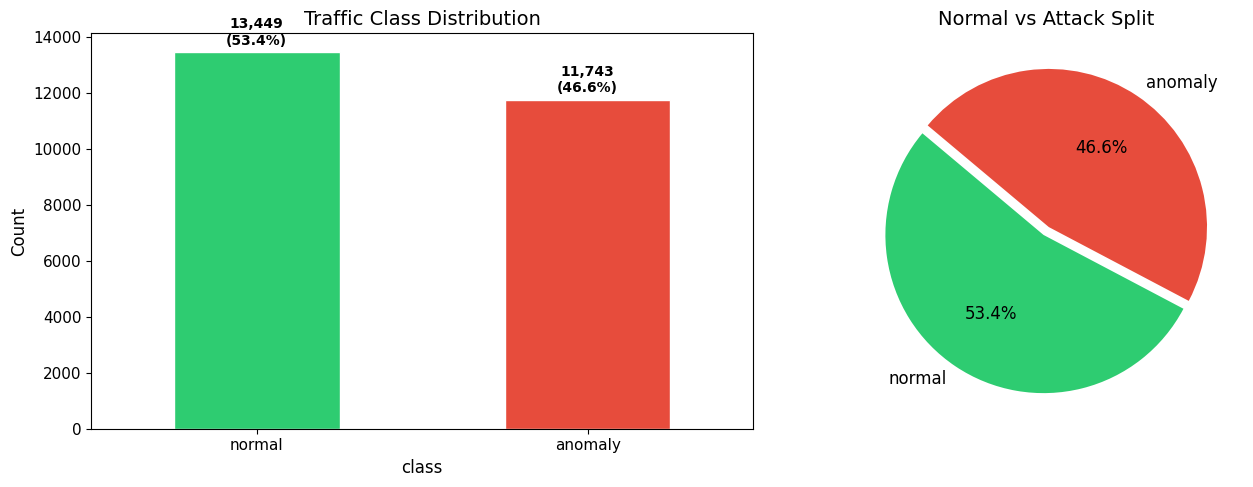

Imbalance ratio (minority/majority): 0.873
→ Reasonably balanced — class weighting still helps but isn't critical


In [5]:
# 2·1 — Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df_raw[TARGET].value_counts()
colors = [C_NORMAL if is_normal(v) else C_ATTACK for v in vc.index]

vc.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Traffic Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + vc.values.max()*0.02, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(vc, labels=vc.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            textprops={'fontsize': 12}, explode=[0.03]*len(vc))
axes[1].set_title('Normal vs Attack Split')

plt.tight_layout()
plt.show()

imbalance_ratio = vc.min() / vc.max()
print(f"Imbalance ratio (minority/majority): {imbalance_ratio:.3f}")
if imbalance_ratio < 0.3:
    print("→ Significant imbalance detected — class_weight='balanced' will be important")
else:
    print("→ Reasonably balanced — class weighting still helps but isn't critical")

Categorical features (excl. target): ['protocol_type', 'service', 'flag']



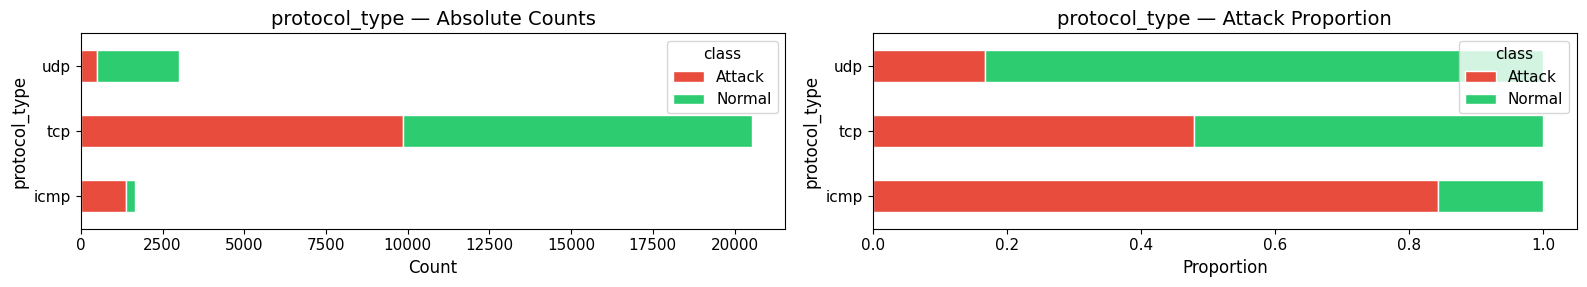

  protocol_type values with >50% attack traffic:
    icmp: 84.2% attack (1,655 connections)



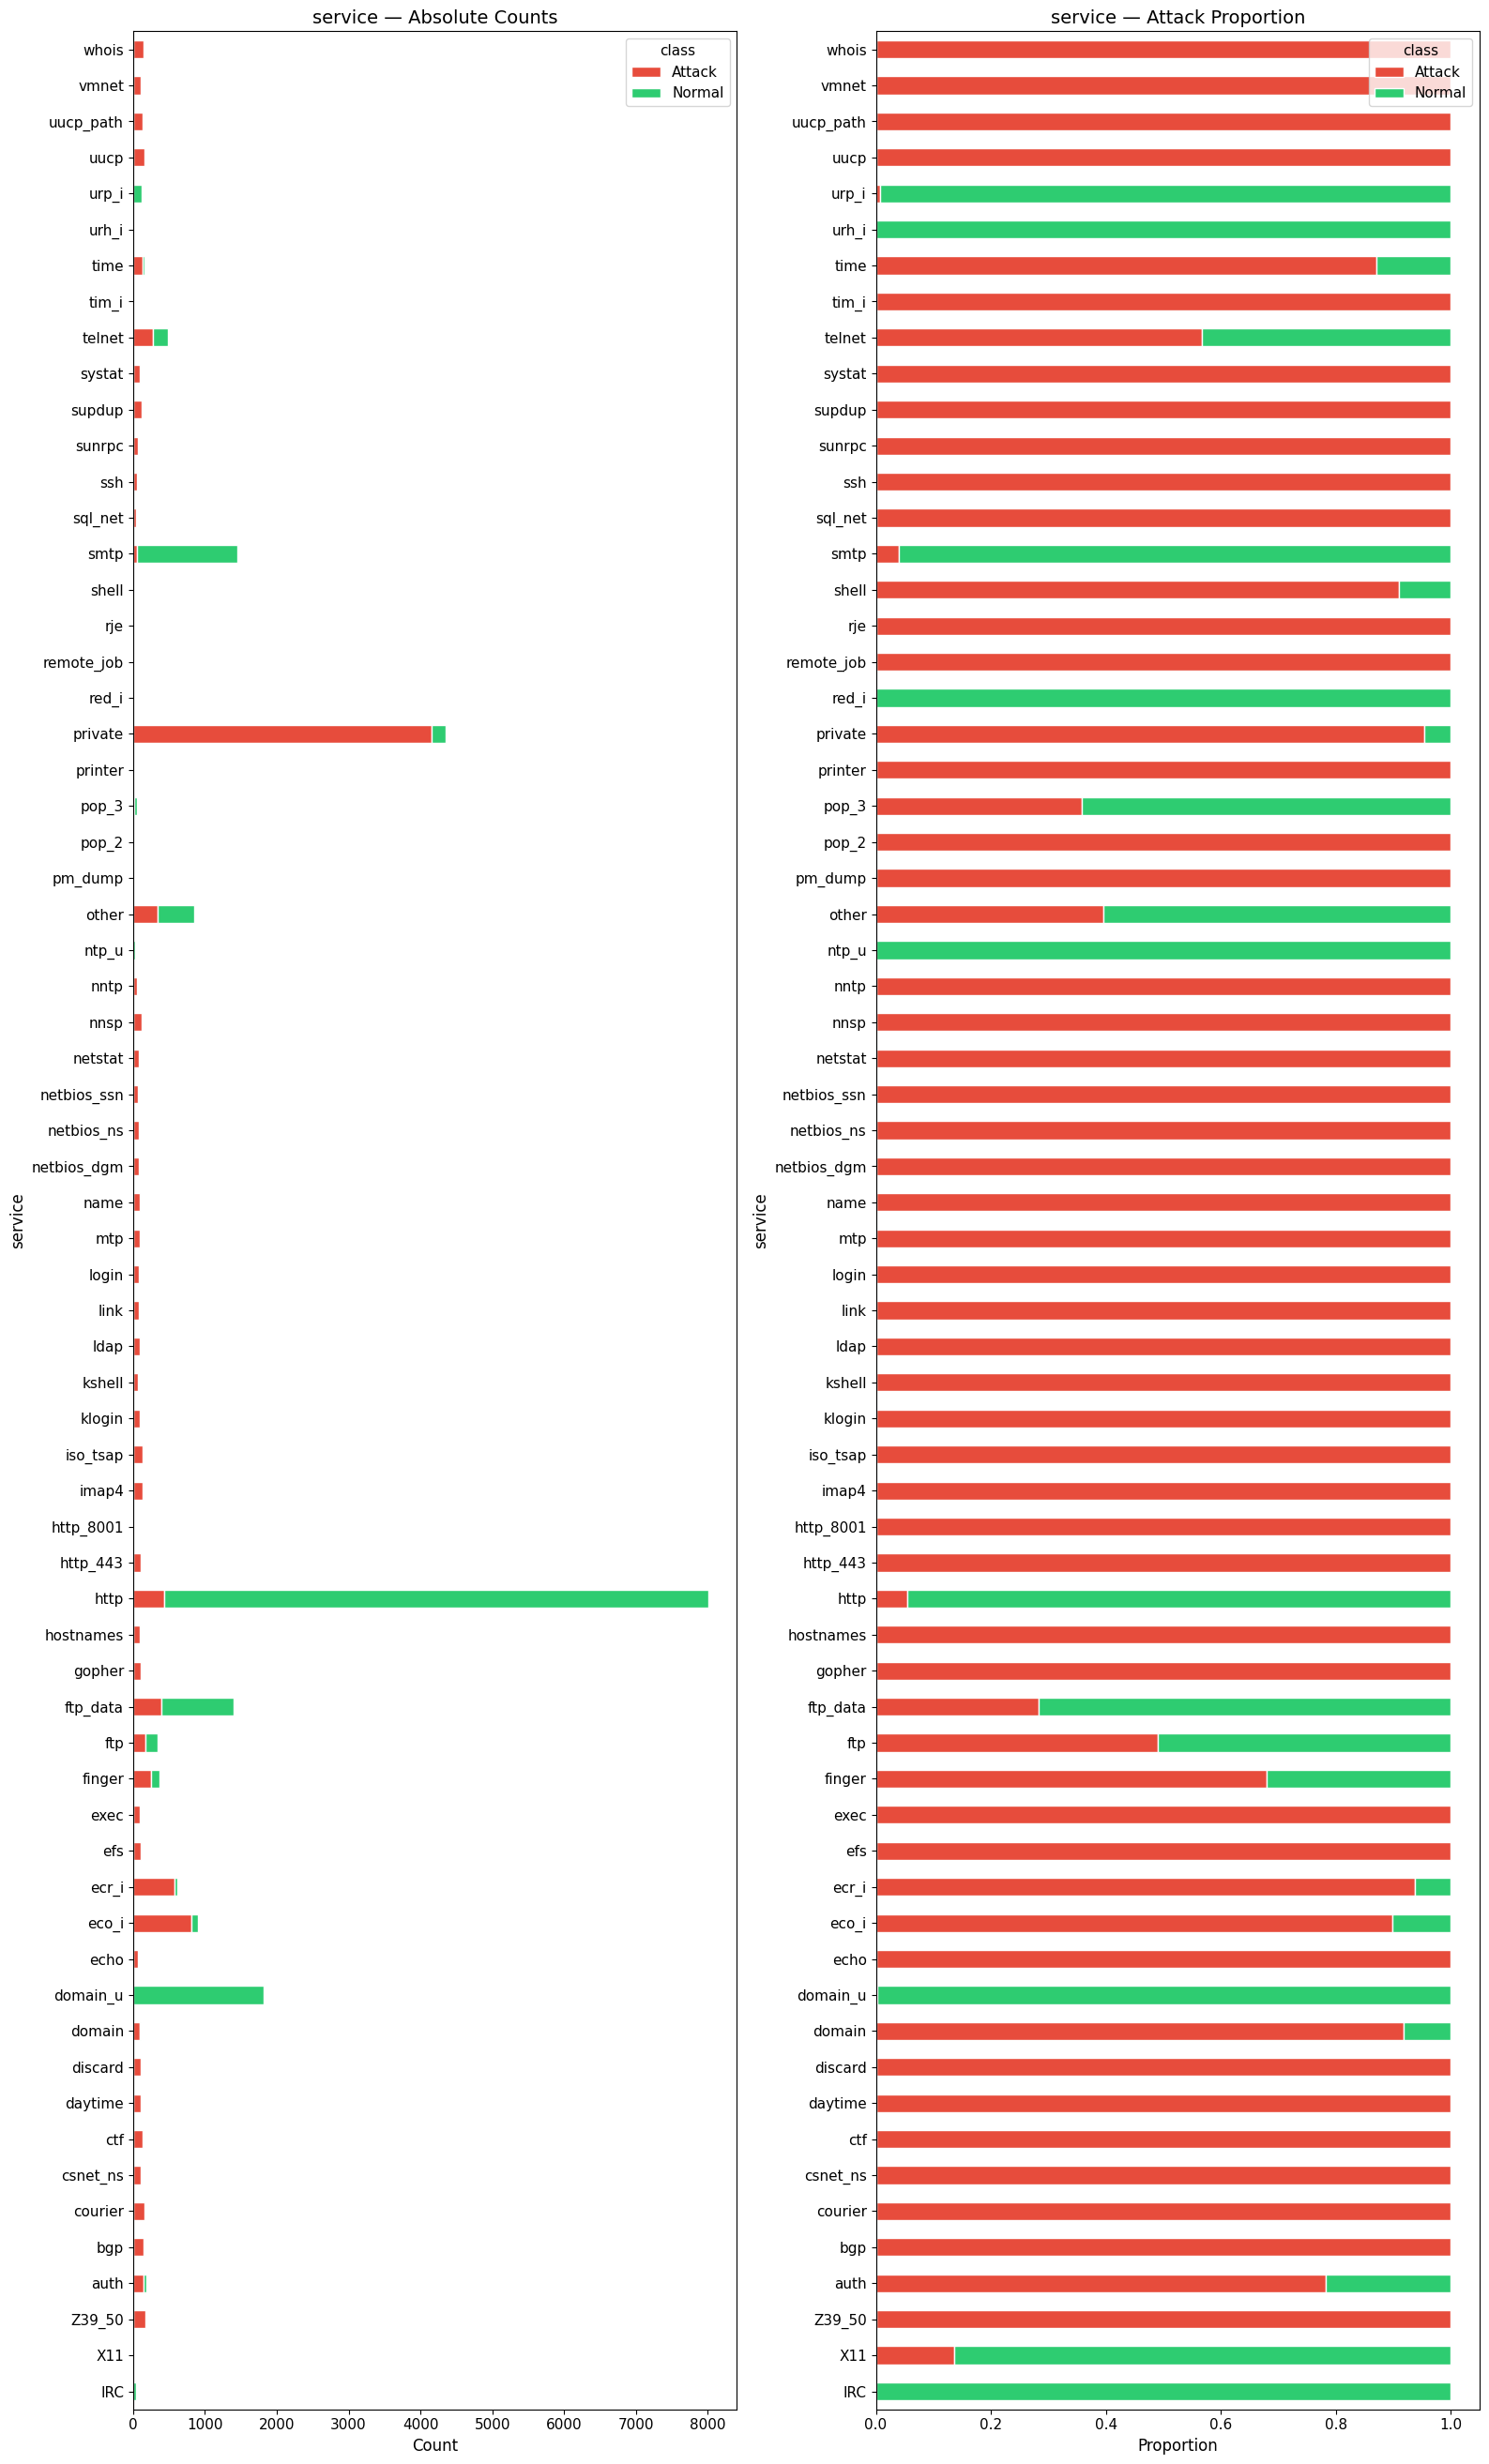

  service values with >50% attack traffic:
    Z39_50: 100.0% attack (172 connections)
    bgp: 100.0% attack (146 connections)
    courier: 100.0% attack (164 connections)
    csnet_ns: 100.0% attack (111 connections)
    ctf: 100.0% attack (127 connections)
    imap4: 100.0% attack (138 connections)
    daytime: 100.0% attack (107 connections)
    discard: 100.0% attack (105 connections)
    echo: 100.0% attack (65 connections)
    efs: 100.0% attack (110 connections)
    hostnames: 100.0% attack (96 connections)
    gopher: 100.0% attack (109 connections)
    exec: 100.0% attack (91 connections)
    iso_tsap: 100.0% attack (131 connections)
    http_8001: 100.0% attack (1 connections)
    http_443: 100.0% attack (113 connections)
    login: 100.0% attack (79 connections)
    link: 100.0% attack (85 connections)
    ldap: 100.0% attack (90 connections)
    kshell: 100.0% attack (67 connections)
    klogin: 100.0% attack (92 connections)
    remote_job: 100.0% attack (17 connections)


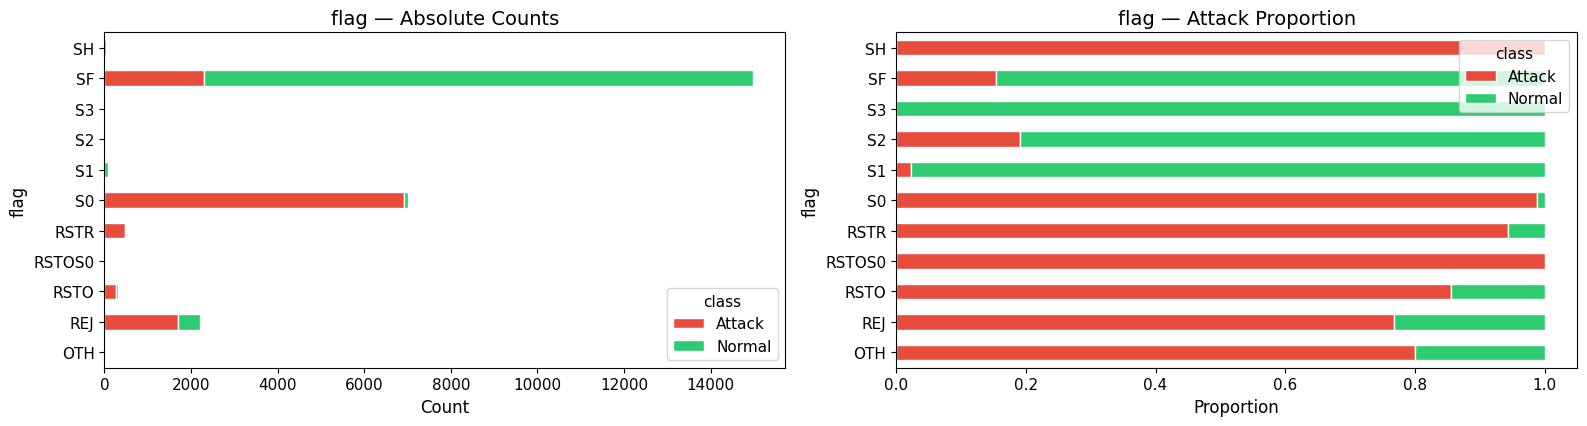

  flag values with >50% attack traffic:
    RSTOS0: 100.0% attack (21 connections)
    SH: 100.0% attack (43 connections)
    S0: 98.9% attack (7,009 connections)
    RSTR: 94.4% attack (497 connections)
    RSTO: 85.5% attack (304 connections)
    OTH: 80.0% attack (5 connections)
    REJ: 76.8% attack (2,216 connections)



In [6]:
# 2·2 — Protocol / flag analysis
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
if TARGET in cat_cols:
    cat_cols.remove(TARGET)

print(f"Categorical features (excl. target): {cat_cols}\n")

for col in cat_cols[:3]:
    ct = pd.crosstab(df_raw[col], df_raw[TARGET].apply(
        lambda x: 'Normal' if is_normal(x) else 'Attack'))
    ct_pct = ct.div(ct.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(3, len(ct_pct)*0.4)))

    # Absolute counts
    ct.plot.barh(stacked=True, ax=axes[0], color=[C_ATTACK, C_NORMAL], edgecolor='white')
    axes[0].set_title(f'{col} — Absolute Counts')
    axes[0].set_xlabel('Count')

    # Proportions
    ct_pct.plot.barh(stacked=True, ax=axes[1], color=[C_ATTACK, C_NORMAL], edgecolor='white')
    axes[1].set_title(f'{col} — Attack Proportion')
    axes[1].set_xlabel('Proportion')

    plt.tight_layout()
    plt.show()

    # Print the most attack-heavy categories
    if 'Attack' in ct_pct.columns:
        high_attack = ct_pct[ct_pct['Attack'] > 0.5].sort_values('Attack', ascending=False)
        if len(high_attack) > 0:
            print(f"  {col} values with >50% attack traffic:")
            for idx, row in high_attack.iterrows():
                total = ct.loc[idx].sum()
                print(f"    {idx}: {row['Attack']:.1%} attack ({total:,} connections)")
            print()

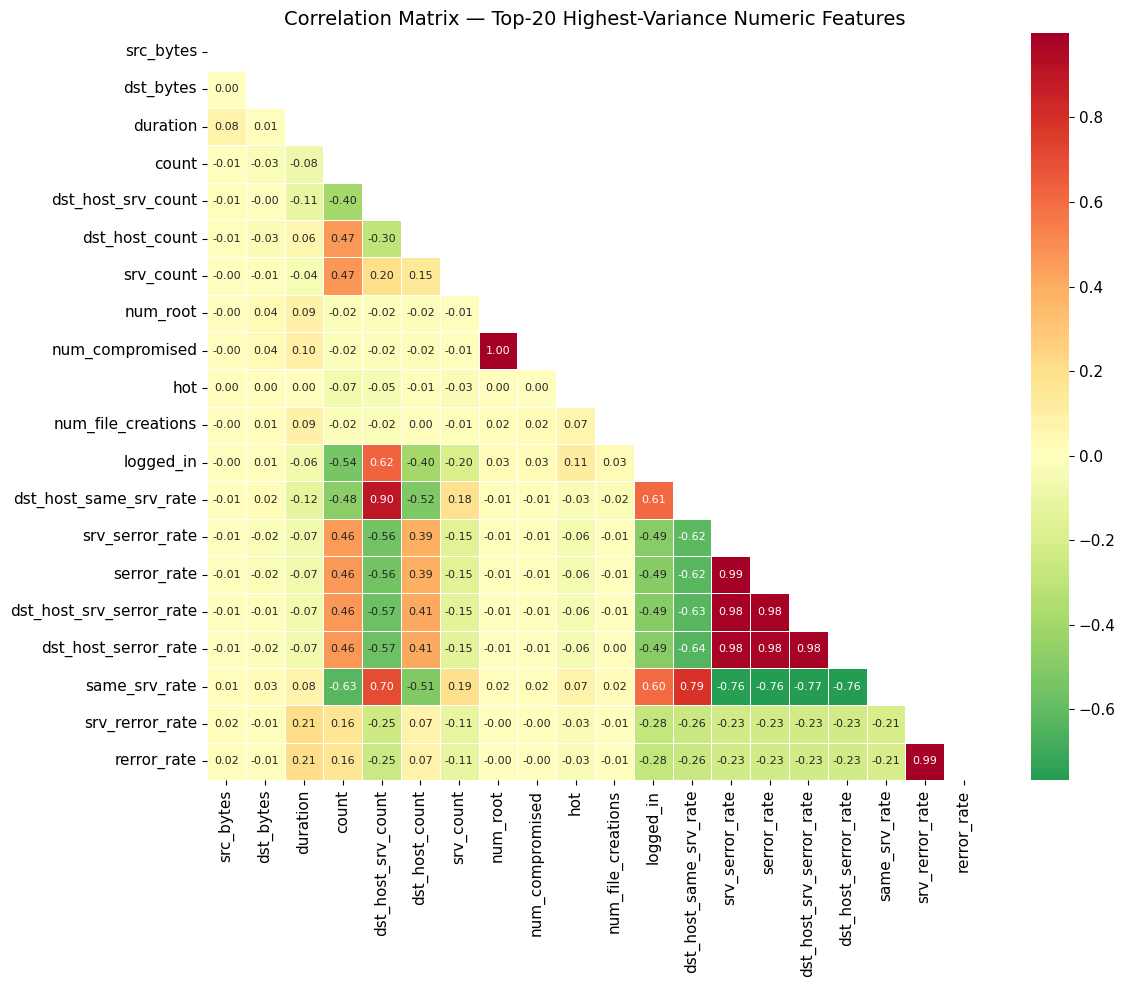


8 highly correlated pairs (|r| > 0.9):
  num_root  ↔  num_compromised  (r=0.999)
  srv_serror_rate  ↔  serror_rate  (r=0.993)
  srv_rerror_rate  ↔  rerror_rate  (r=0.989)
  dst_host_srv_serror_rate  ↔  dst_host_serror_rate  (r=0.985)
  srv_serror_rate  ↔  dst_host_srv_serror_rate  (r=0.985)
  serror_rate  ↔  dst_host_srv_serror_rate  (r=0.980)
  serror_rate  ↔  dst_host_serror_rate  (r=0.978)
  srv_serror_rate  ↔  dst_host_serror_rate  (r=0.976)
  → In production, consider dropping one from each pair to reduce dimensionality


In [7]:
# 2·3 — Numeric feature correlations (top-20 most varying)
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
top_var = df_raw[num_cols].var().nlargest(20).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_raw[top_var].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, fmt='.2f',
            annot=True, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Top-20 Highest-Variance Numeric Features')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (potential for removal)
high_corr_pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print(f"\n{len(high_corr_pairs)} highly correlated pairs (|r| > 0.9):")
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f"  {a}  ↔  {b}  (r={r:.3f})")
    print("  → In production, consider dropping one from each pair to reduce dimensionality")

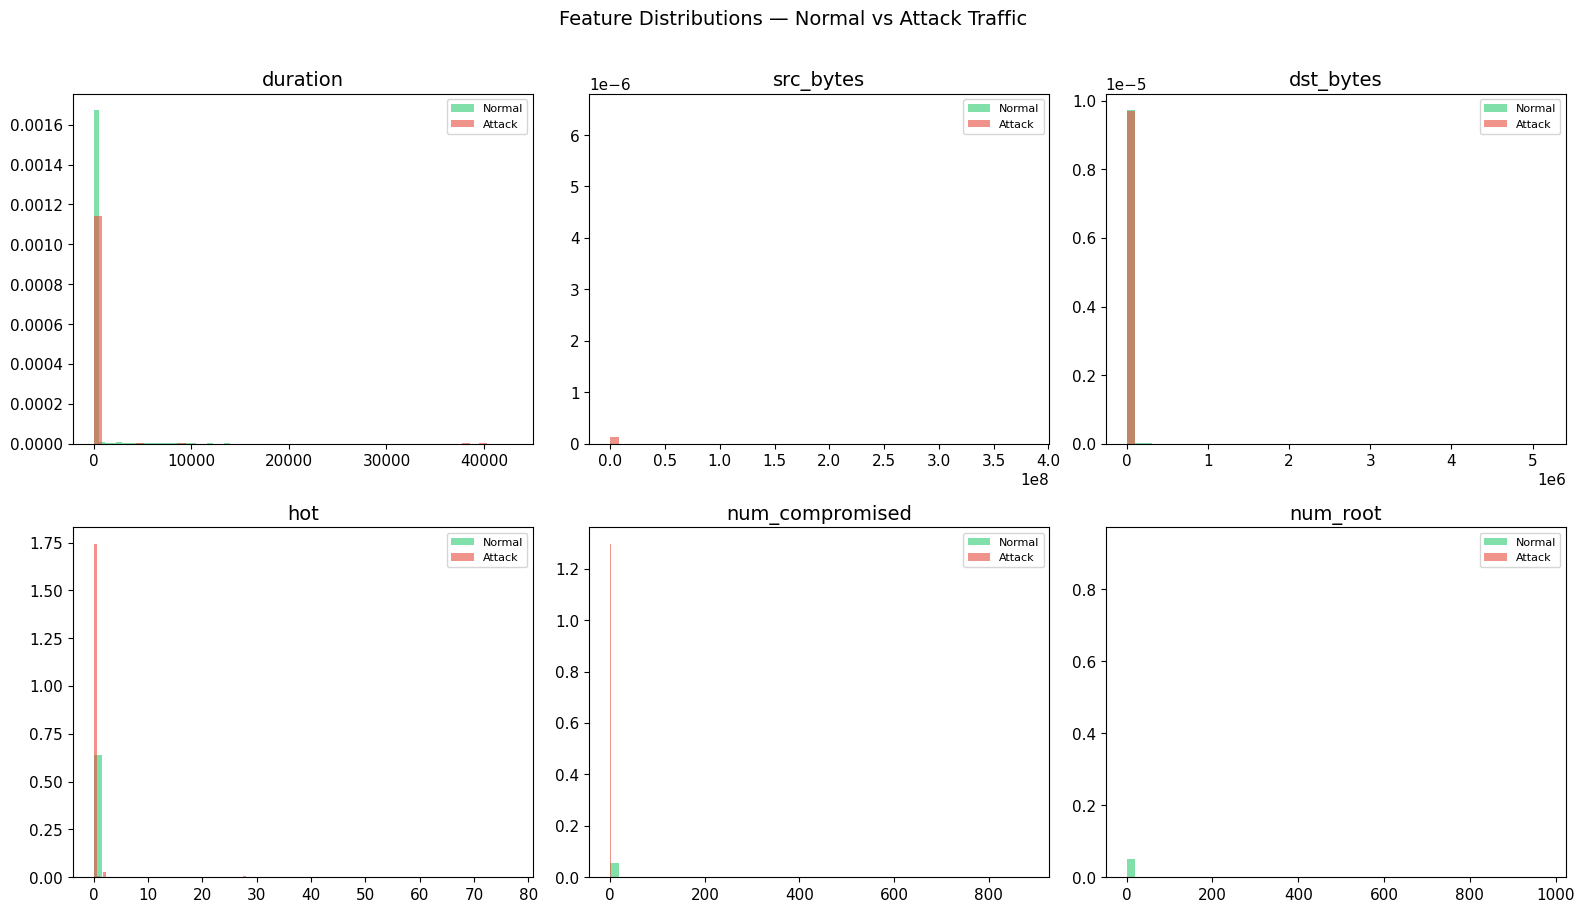

In [8]:
# 2·4 — Feature distributions: normal vs attack
binary_label = df_raw[TARGET].apply(lambda x: 'Normal' if is_normal(x) else 'Attack')

# Select features with enough variation to be interesting
plot_cols = [c for c in num_cols if df_raw[c].nunique() > 10][:6]

if plot_cols:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, col in zip(axes.flatten(), plot_cols):
        for label, color in [('Normal', C_NORMAL), ('Attack', C_ATTACK)]:
            subset = df_raw.loc[binary_label == label, col]
            ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(col)
        ax.legend(fontsize=8)
    plt.suptitle('Feature Distributions — Normal vs Attack Traffic', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

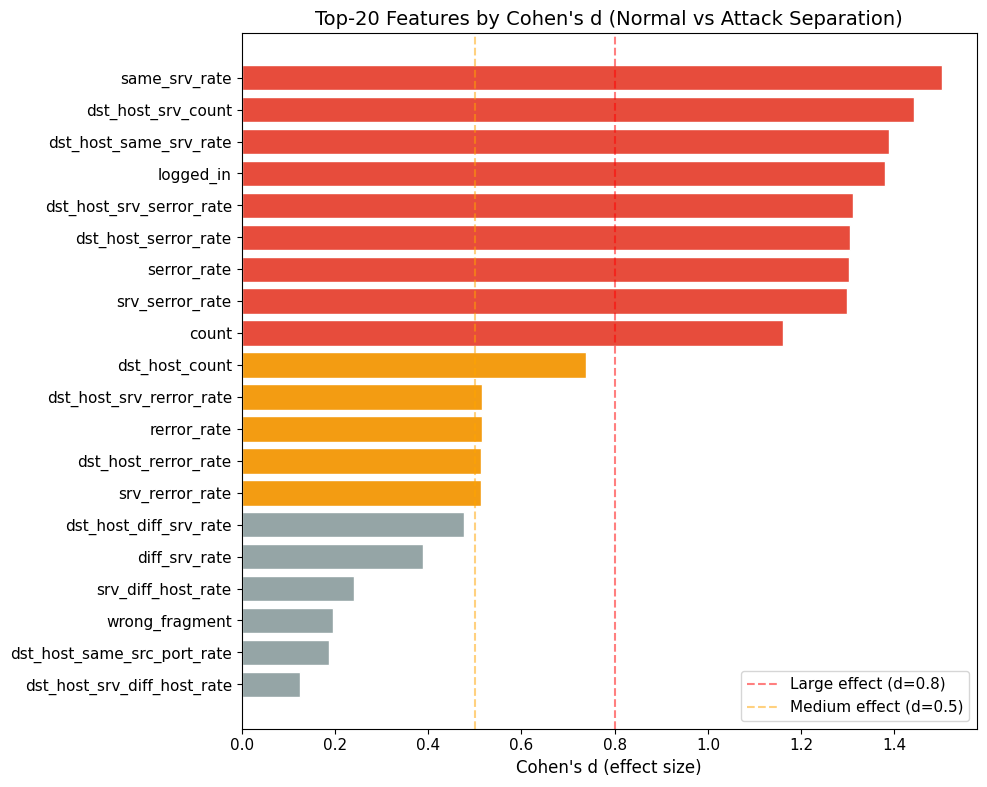


14 features with medium+ separation (d > 0.5): ['srv_rerror_rate', 'dst_host_rerror_rate', 'rerror_rate', 'dst_host_srv_rerror_rate', 'dst_host_count', 'count', 'srv_serror_rate', 'serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'logged_in', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'same_srv_rate']


In [9]:
# 2·5 — Statistical separation: which features best distinguish normal from attack?
normal_mask = binary_label == 'Normal'
attack_mask = binary_label == 'Attack'

sep_scores = []
for col in num_cols:
    n_mean = df_raw.loc[normal_mask, col].mean()
    a_mean = df_raw.loc[attack_mask, col].mean()
    pooled_std = df_raw[col].std()
    if pooled_std > 0:
        cohen_d = abs(n_mean - a_mean) / pooled_std
    else:
        cohen_d = 0
    sep_scores.append({'feature': col, 'cohen_d': cohen_d,
                       'normal_mean': n_mean, 'attack_mean': a_mean})

sep_df = pd.DataFrame(sep_scores).sort_values('cohen_d', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
top_sep = sep_df.tail(20)
colors_sep = ['#e74c3c' if d > 0.8 else '#f39c12' if d > 0.5 else '#95a5a6'
              for d in top_sep['cohen_d']]
ax.barh(top_sep['feature'], top_sep['cohen_d'], color=colors_sep, edgecolor='white')
ax.set_title("Top-20 Features by Cohen's d (Normal vs Attack Separation)")
ax.set_xlabel("Cohen's d (effect size)")
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect (d=0.8)')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect (d=0.5)')
ax.legend()
plt.tight_layout()
plt.show()

strong_features = sep_df[sep_df['cohen_d'] > 0.5]['feature'].tolist()
print(f"\n{len(strong_features)} features with medium+ separation (d > 0.5): {strong_features}")

## 3 · Feature Engineering & Preprocessing

In a production IDS pipeline this stage is critical — raw NetFlow/pcap features need encoding, scaling, and interaction terms before they hit the model.  
Key decisions:
- **Label-encode** categoricals (tree models handle ordinals fine).
- **StandardScaler** on numerics — essential for Logistic Regression convergence.
- Create **interaction features** encoding domain knowledge (bytes-per-second, error ratios, zero-duration flags).

In [10]:
df = df_raw.copy()

# ── Encode categoricals ──
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {len(le.classes_)} classes")

# ── Encode target ──
le_target = LabelEncoder()
df['target_encoded'] = le_target.fit_transform(df[TARGET].astype(str))
class_names = le_target.classes_
print(f"\nTarget classes ({len(class_names)}): {list(class_names)}")

# Map to binary: 1 = attack, 0 = normal
normal_encoded = le_target.transform([str(NORMAL_CLASS)])[0]
print(f"Normal class '{NORMAL_CLASS}' → encoded as {normal_encoded}")

  Encoded 'protocol_type' → 3 classes
  Encoded 'service' → 66 classes
  Encoded 'flag' → 11 classes

Target classes (2): ['anomaly', 'normal']
Normal class 'normal' → encoded as 1


In [11]:
# ── Interaction features (domain-motivated) ──
def safe_ratio(df, num, den, name):
    if num in df.columns and den in df.columns:
        df[name] = df[num] / (df[den] + 1)
        print(f"  Created '{name}'")

safe_ratio(df, 'src_bytes', 'duration', 'bytes_per_sec_src')
safe_ratio(df, 'dst_bytes', 'duration', 'bytes_per_sec_dst')
safe_ratio(df, 'srv_serror_rate', 'serror_rate', 'srv_serror_ratio')
safe_ratio(df, 'dst_host_srv_count', 'dst_host_count', 'srv_count_ratio')

if 'duration' in df.columns:
    df['zero_duration'] = (df['duration'] == 0).astype(int)
    print("  Created 'zero_duration'")

# Log-transform heavy-tailed features
for col in ['src_bytes', 'dst_bytes', 'duration']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])
        print(f"  Created 'log_{col}'")

print(f"\nFinal feature count: {df.shape[1] - 2}")

  Created 'bytes_per_sec_src'
  Created 'bytes_per_sec_dst'
  Created 'srv_serror_ratio'
  Created 'srv_count_ratio'
  Created 'zero_duration'
  Created 'log_src_bytes'
  Created 'log_dst_bytes'
  Created 'log_duration'

Final feature count: 49


In [12]:
# ── Prepare X, y ──
drop_cols = [TARGET, 'target_encoded']
feature_cols = [c for c in df.columns if c not in drop_cols]

X_all = df[feature_cols]
y_all = (df['target_encoded'].values != normal_encoded).astype(int)  # 1=attack, 0=normal

MAX_ROWS = 100_000
if len(X_all) > MAX_ROWS:
    X_sample, _, y_sample, _ = train_test_split(
        X_all, y_all, train_size=MAX_ROWS, stratify=y_all, random_state=42)
    X_sample = X_sample.reset_index(drop=True)
    print(f"Stratified subsample: {len(X_all):,} → {MAX_ROWS:,} rows")
else:
    X_sample = X_all.reset_index(drop=True)
    y_sample = y_all.copy()
    print(f"Using full dataset: {len(X_sample):,} rows")

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_sample), columns=feature_cols)

print(f"X shape: {X_scaled.shape}")
print(f"y: {(y_sample==0).sum():,} normal  |  {(y_sample==1).sum():,} attack  |  attack ratio: {y_sample.mean():.1%}")

Using full dataset: 25,192 rows
X shape: (25192, 49)
y: 13,449 normal  |  11,743 attack  |  attack ratio: 46.6%


## 4 · Attack Pattern Analysis

Even with binary labels, we can profile *what makes attack traffic different* from normal. This is the kind of intelligence SOC analysts feed into playbooks and SIEM correlation rules.

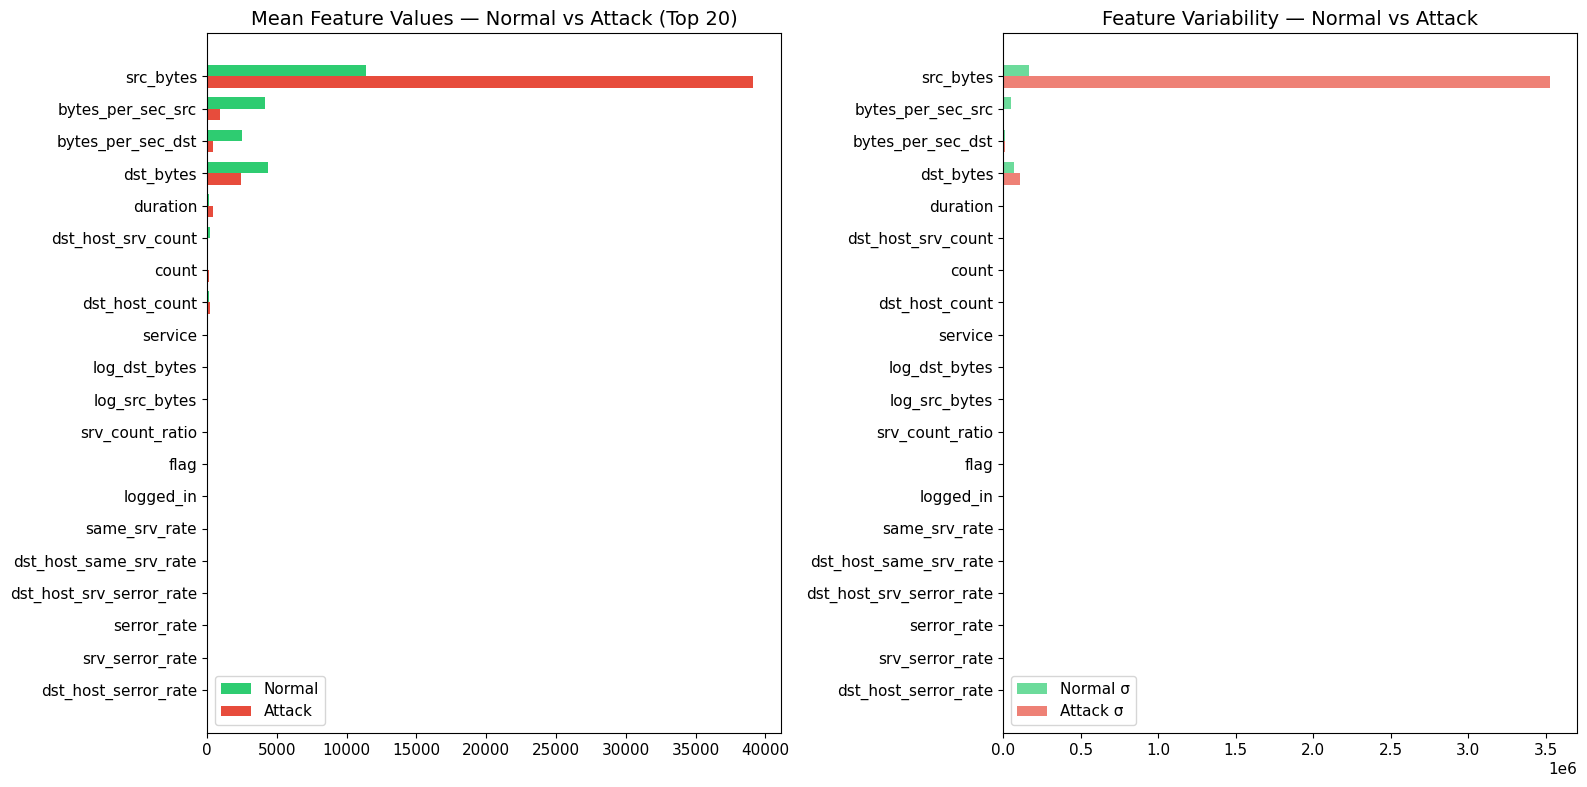

In [13]:
# 4·1 — Feature profiles: attack vs normal
attack_mask = y_all == 1
normal_mask = y_all == 0

profile = pd.DataFrame({
    'normal_mean': X_all.loc[normal_mask].mean(),
    'attack_mean': X_all.loc[attack_mask].mean(),
    'normal_std': X_all.loc[normal_mask].std(),
    'attack_std': X_all.loc[attack_mask].std(),
})
profile['diff'] = (profile['attack_mean'] - profile['normal_mean']).abs()
profile = profile.sort_values('diff', ascending=False)

# Top distinguishing features
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top20 = profile.head(20)
x = np.arange(len(top20))
width = 0.35

axes[0].barh(x - width/2, top20['normal_mean'], width, label='Normal', color=C_NORMAL)
axes[0].barh(x + width/2, top20['attack_mean'], width, label='Attack', color=C_ATTACK)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top20.index)
axes[0].set_title('Mean Feature Values — Normal vs Attack (Top 20)')
axes[0].legend()
axes[0].invert_yaxis()

# Variance comparison
axes[1].barh(x - width/2, top20['normal_std'], width, label='Normal σ', color=C_NORMAL, alpha=0.7)
axes[1].barh(x + width/2, top20['attack_std'], width, label='Attack σ', color=C_ATTACK, alpha=0.7)
axes[1].set_yticks(x)
axes[1].set_yticklabels(top20.index)
axes[1].set_title('Feature Variability — Normal vs Attack')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
# 4·2 — Protocol breakdown (if protocol_type exists)
if 'protocol_type' in df_raw.columns:
    proto_ct = pd.crosstab(df_raw['protocol_type'], binary_label, normalize='index')
    print("Attack rate by protocol:")
    for proto in proto_ct.index:
        attack_rate = proto_ct.loc[proto, 'Attack'] if 'Attack' in proto_ct.columns else 0
        total = df_raw[df_raw['protocol_type'] == proto].shape[0]
        print(f"  {proto:10s}: {attack_rate:.1%} attack  ({total:,} connections)")

# Connection flag analysis (if flag column exists)
if 'flag' in df_raw.columns:
    print("\nAttack rate by connection flag:")
    flag_ct = pd.crosstab(df_raw['flag'], binary_label, normalize='index')
    if 'Attack' in flag_ct.columns:
        flag_ct_sorted = flag_ct.sort_values('Attack', ascending=False)
        for flag in flag_ct_sorted.index:
            total = df_raw[df_raw['flag'] == flag].shape[0]
            print(f"  {flag:10s}: {flag_ct_sorted.loc[flag, 'Attack']:.1%} attack  ({total:,} connections)")

Attack rate by protocol:
  icmp      : 84.2% attack  (1,655 connections)
  tcp       : 48.0% attack  (20,526 connections)
  udp       : 16.7% attack  (3,011 connections)

Attack rate by connection flag:
  RSTOS0    : 100.0% attack  (21 connections)
  SH        : 100.0% attack  (43 connections)
  S0        : 98.9% attack  (7,009 connections)
  RSTR      : 94.4% attack  (497 connections)
  RSTO      : 85.5% attack  (304 connections)
  OTH       : 80.0% attack  (5 connections)
  REJ       : 76.8% attack  (2,216 connections)
  S2        : 19.0% attack  (21 connections)
  SF        : 15.4% attack  (14,973 connections)
  S1        : 2.3% attack  (88 connections)
  S3        : 0.0% attack  (15 connections)


## 5 · Model Training & Comparison

We compare four classifiers commonly used in production IDS systems:

| Model | Why include it? |
|---|---|
| **Logistic Regression** | Fast baseline; interpretable coefficients; real-time scoring at line rate |
| **Random Forest** | Robust to noise; interpretable via feature importances |
| **XGBoost** | Industry standard for tabular data; handles imbalance well |
| **LightGBM** | Fastest GBDT; ideal for high-throughput network telemetry |

**CV strategy:** 3-fold stratified  
**Imbalance handling:** `class_weight='balanced'` — no SMOTE/ADASYN (compute cost without proportional lift)

In [15]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', solver='lbfgs',
        n_jobs=-1, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=42, max_depth=15),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        tree_method='hist', eval_metric='logloss',
        use_label_encoder=False, n_jobs=-1, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1),
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print(f"Training on {len(X_scaled):,} rows × {X_scaled.shape[1]} features")
print(f"3-fold CV with {len(models)} models\n")

Training on 25,192 rows × 49 features
3-fold CV with 4 models



In [16]:
# ── Train with OOF predictions for all metrics ──
results = {}
oof_probs = {}

for name, model in models.items():
    print(f"{'='*55}")
    print(f"  {name}")
    t0 = time.time()

    oof_prob = np.zeros(len(y_sample))
    oof_pred = np.zeros(len(y_sample))
    fold_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_scaled, y_sample)):
        model.fit(X_scaled.iloc[tr_idx], y_sample[tr_idx])
        prob = model.predict_proba(X_scaled.iloc[va_idx])[:, 1]
        pred = (prob >= 0.5).astype(int)
        oof_prob[va_idx] = prob
        oof_pred[va_idx] = pred

        f1_val = f1_score(y_sample[va_idx], pred)
        print(f"    Fold {fold+1}: F1={f1_val:.4f}")

    elapsed = time.time() - t0
    oof_probs[name] = oof_prob

    results[name] = {
        'accuracy': accuracy_score(y_sample, oof_pred),
        'precision': precision_score(y_sample, oof_pred),
        'recall': recall_score(y_sample, oof_pred),
        'f1': f1_score(y_sample, oof_pred),
        'f1_macro': f1_score(y_sample, oof_pred, average='macro'),
        'f1_weighted': f1_score(y_sample, oof_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_sample, oof_prob),
        'time_sec': elapsed,
    }
    print(f"    OOF:  AUC={results[name]['roc_auc']:.4f}  F1={results[name]['f1']:.4f}  "
          f"Prec={results[name]['precision']:.4f}  Rec={results[name]['recall']:.4f}  "
          f"({elapsed:.1f}s)")

res_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
print("\n✓ All models trained")
res_df.round(4)

  Logistic Regression
    Fold 1: F1=0.9547
    Fold 2: F1=0.9616
    Fold 3: F1=0.9574
    OOF:  AUC=0.9922  F1=0.9579  Prec=0.9572  Rec=0.9586  (5.6s)
  Random Forest
    Fold 1: F1=0.9982
    Fold 2: F1=0.9974
    Fold 3: F1=0.9958
    OOF:  AUC=0.9999  F1=0.9971  Prec=0.9987  Rec=0.9956  (2.4s)
  XGBoost
    Fold 1: F1=0.9983
    Fold 2: F1=0.9981
    Fold 3: F1=0.9946
    OOF:  AUC=0.9999  F1=0.9970  Prec=0.9983  Rec=0.9957  (1.4s)
  LightGBM
    Fold 1: F1=0.9974
    Fold 2: F1=0.9985
    Fold 3: F1=0.9959
    OOF:  AUC=0.9999  F1=0.9973  Prec=0.9984  Rec=0.9962  (1.5s)

✓ All models trained


,accuracy,precision,recall,f1,f1_macro,f1_weighted,roc_auc,time_sec
Random Forest,0.9973,0.9987,0.9956,0.9971,0.9973,0.9973,0.9999,2.4462
LightGBM,0.9975,0.9984,0.9962,0.9973,0.9974,0.9975,0.9999,1.4949
XGBoost,0.9972,0.9983,0.9957,0.9970,0.9972,0.9972,0.9999,1.3508
Logistic Regression,0.9607,0.9572,0.9586,0.9579,0.9606,0.9607,0.9922,5.5503


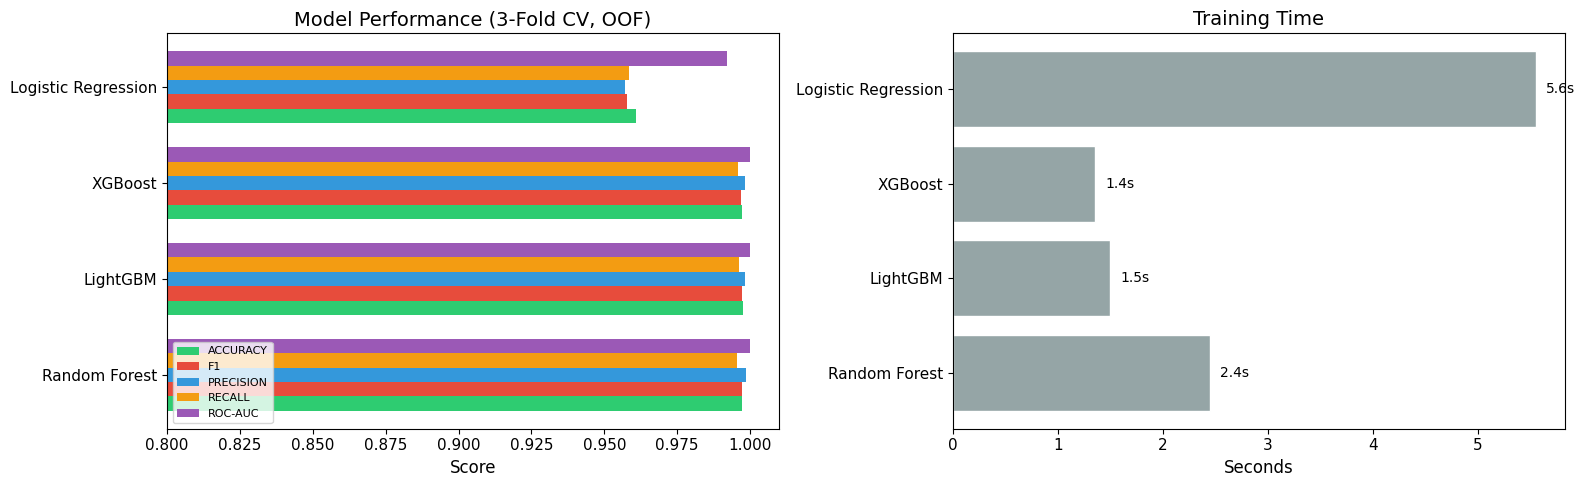

In [17]:
# ── Performance comparison chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
x = np.arange(len(res_df))
width = 0.15
colors_m = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    axes[0].barh(x + i*width, res_df[metric], width,
                 label=metric.upper().replace('_', '-'), color=colors_m[i])
axes[0].set_yticks(x + 2*width)
axes[0].set_yticklabels(res_df.index)
axes[0].set_xlim(0.8, 1.01)
axes[0].set_title('Model Performance (3-Fold CV, OOF)')
axes[0].legend(loc='lower left', fontsize=8)
axes[0].set_xlabel('Score')

axes[1].barh(res_df.index, res_df['time_sec'], color='#95a5a6', edgecolor='white')
axes[1].set_title('Training Time')
axes[1].set_xlabel('Seconds')
for i, v in enumerate(res_df['time_sec'].values):
    axes[1].text(v + 0.1, i, f'{v:.1f}s', va='center', fontsize=10)

plt.tight_layout()
plt.show()

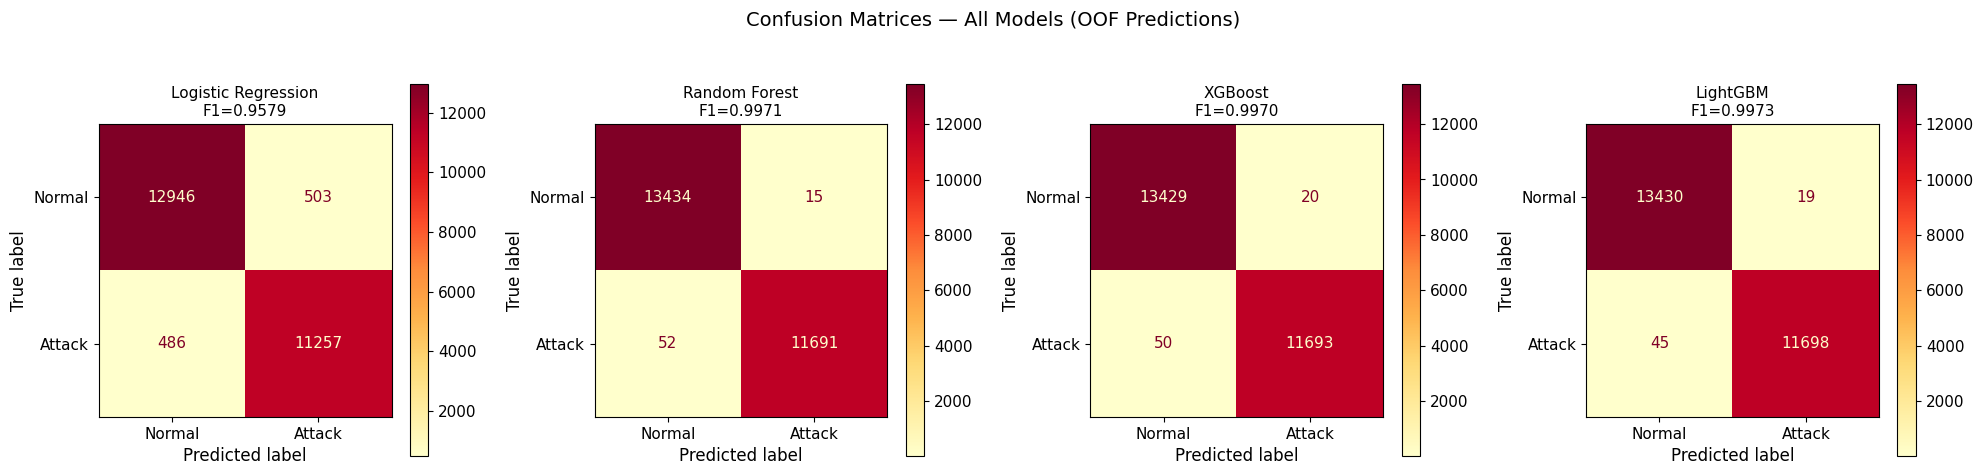

In [18]:
# ── Confusion matrices for all models ──
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4.5))

for ax, (name, probs) in zip(axes, oof_probs.items()):
    pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_sample, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=ax, cmap='YlOrRd', values_format='d')
    ax.set_title(f'{name}\nF1={results[name]["f1"]:.4f}', fontsize=11)

plt.suptitle('Confusion Matrices — All Models (OOF Predictions)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 6 · Threshold Tuning & Operating Point Selection

The default 0.5 threshold is rarely optimal for a production IDS. The right threshold depends on your environment:

- **High-value government network** → maximise recall (catch everything, tolerate more false positives)
- **High-traffic commercial network** → maximise precision (reduce alert fatigue for SOC analysts)
- **Balanced SOC** → optimise F1

This section lets you pick the operating point that matches your deployment context.

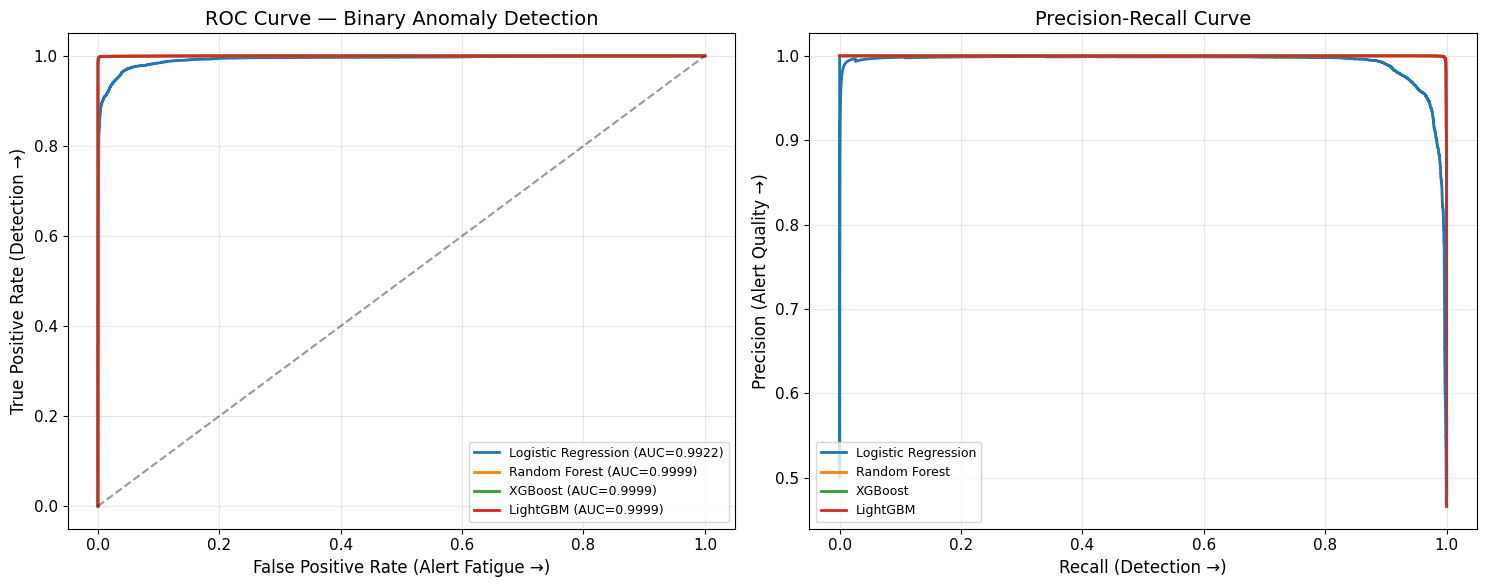

In [19]:
# ── ROC and Precision-Recall curves ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, probs in oof_probs.items():
    fpr, tpr, _ = roc_curve(y_sample, probs)
    auc_val = results[name]['roc_auc']
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curve — Binary Anomaly Detection')
axes[0].set_xlabel('False Positive Rate (Alert Fatigue →)')
axes[0].set_ylabel('True Positive Rate (Detection →)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, probs in oof_probs.items():
    prec, rec, _ = precision_recall_curve(y_sample, probs)
    axes[1].plot(rec, prec, label=name, linewidth=2)

axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall (Detection →)')
axes[1].set_ylabel('Precision (Alert Quality →)')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

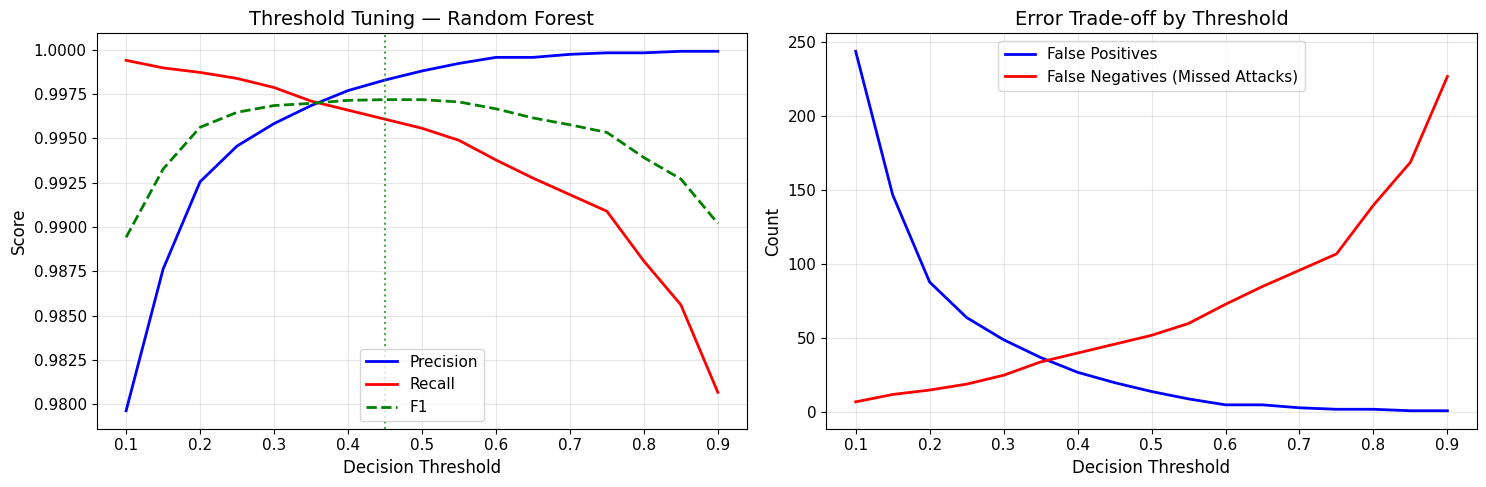

Best F1 threshold: 0.45

Operating point recommendations:
  High-security (govt):  threshold=0.30  →  maximise recall, accept more FPs
  Balanced SOC:          threshold=0.45  →  optimise F1
  Alert-fatigued SOC:    threshold=0.70  →  only high-confidence alerts


In [20]:
# ── Threshold analysis for the best model ──
best_name = res_df.index[0]
best_probs = oof_probs[best_name]

thresholds = np.arange(0.1, 0.95, 0.05)
thresh_results = []

for t in thresholds:
    pred = (best_probs >= t).astype(int)
    thresh_results.append({
        'threshold': t,
        'precision': precision_score(y_sample, pred, zero_division=0),
        'recall': recall_score(y_sample, pred, zero_division=0),
        'f1': f1_score(y_sample, pred, zero_division=0),
        'fp_count': ((pred == 1) & (y_sample == 0)).sum(),
        'fn_count': ((pred == 0) & (y_sample == 1)).sum(),
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], 'g--', label='F1', linewidth=2)
axes[0].set_title(f'Threshold Tuning — {best_name}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Optimal thresholds
best_f1_thresh = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
axes[0].axvline(x=best_f1_thresh, color='green', linestyle=':', alpha=0.7,
                label=f'Best F1 @ {best_f1_thresh:.2f}')

axes[1].plot(thresh_df['threshold'], thresh_df['fp_count'], 'b-', label='False Positives', linewidth=2)
axes[1].plot(thresh_df['threshold'], thresh_df['fn_count'], 'r-', label='False Negatives (Missed Attacks)', linewidth=2)
axes[1].set_title('Error Trade-off by Threshold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_f1_thresh:.2f}")
print(f"\nOperating point recommendations:")
print(f"  High-security (govt):  threshold=0.30  →  maximise recall, accept more FPs")
print(f"  Balanced SOC:          threshold={best_f1_thresh:.2f}  →  optimise F1")
print(f"  Alert-fatigued SOC:    threshold=0.70  →  only high-confidence alerts")

## 7 · Model Interpretability

In government and regulated environments, *"the model says it's an attack"* isn't enough. SOC analysts and compliance teams need to know **which features drove the prediction**. This aligns with:
- **ASD Essential Eight** — logging and monitoring must be auditable
- **ACSC ISM** — security controls require transparency in automated decision-making

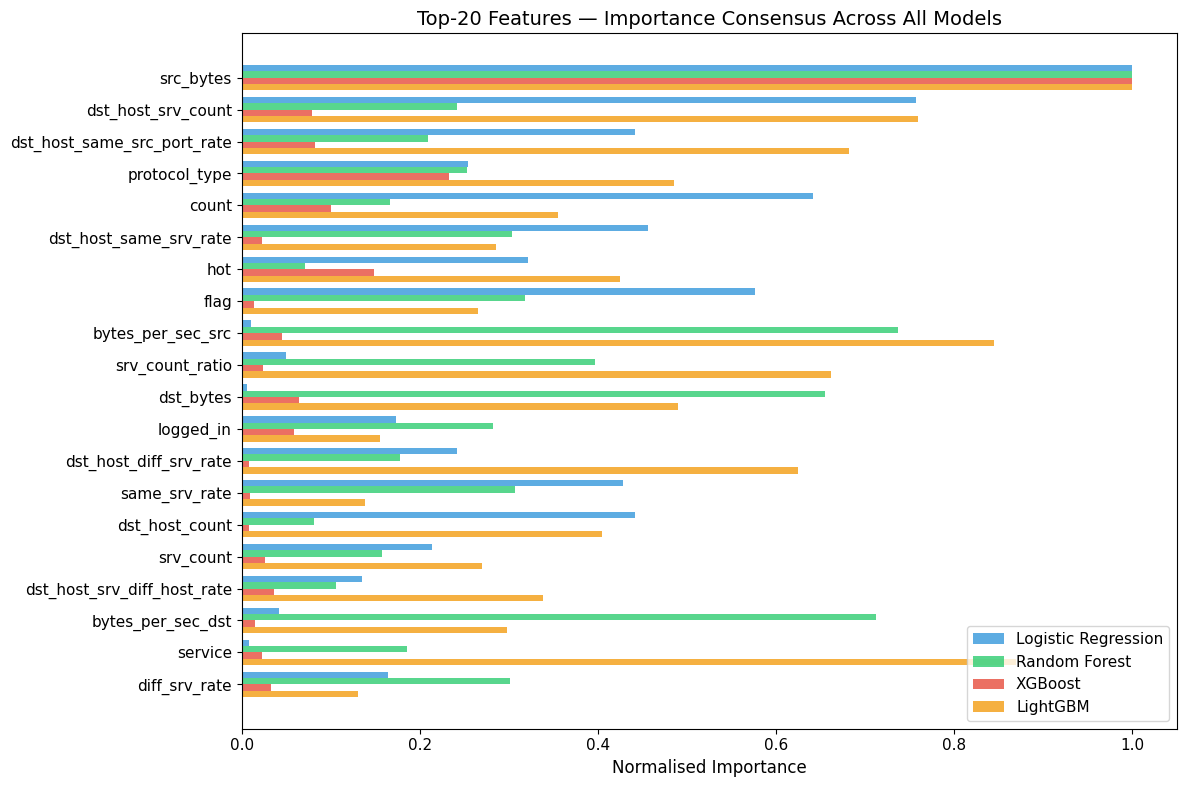

Top-10 features (consensus ranking):
   1. src_bytes
   2. dst_host_srv_count
   3. dst_host_same_src_port_rate
   4. protocol_type
   5. count
   6. dst_host_same_srv_rate
   7. hot
   8. flag
   9. bytes_per_sec_src
  10. srv_count_ratio


In [21]:
# ── 7·1  Feature importance comparison across models ──
importance_data = {}
for name, model in models.items():
    model.fit(X_scaled, y_sample)  # fit on full sample
    if hasattr(model, 'feature_importances_'):
        importance_data[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance_data[name] = np.abs(model.coef_[0])

imp_compare = pd.DataFrame(importance_data, index=feature_cols)

# Rank-based consensus: average rank across models
for col in imp_compare.columns:
    imp_compare[f'{col}_rank'] = imp_compare[col].rank(ascending=False)

rank_cols = [c for c in imp_compare.columns if '_rank' in c]
imp_compare['avg_rank'] = imp_compare[rank_cols].mean(axis=1)
imp_compare = imp_compare.sort_values('avg_rank')

top20 = imp_compare.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(top20))
width = 0.2
model_names = list(importance_data.keys())
colors_imp = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, mname in enumerate(model_names):
    # Normalise to 0-1 for comparison
    vals = top20[mname].values
    vals_norm = vals / (vals.max() + 1e-9)
    ax.barh(x + i*width, vals_norm, width, label=mname, color=colors_imp[i], alpha=0.8)

ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(top20.index)
ax.set_title('Top-20 Features — Importance Consensus Across All Models')
ax.set_xlabel('Normalised Importance')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top-10 features (consensus ranking):")
for i, feat in enumerate(imp_compare.head(10).index):
    print(f"  {i+1:2d}. {feat}")

In [22]:
# ── 7·2  Classification report for the best model ──
best_pred = (oof_probs[best_name] >= 0.5).astype(int)
print(f"Classification Report — {best_name} (OOF predictions)\n")
print(classification_report(y_sample, best_pred, target_names=['Normal', 'Attack']))

Classification Report — Random Forest (OOF predictions)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13449
      Attack       1.00      1.00      1.00     11743

    accuracy                           1.00     25192
   macro avg       1.00      1.00      1.00     25192
weighted avg       1.00      1.00      1.00     25192



## 8 · Production Deployment Considerations

Building a model is step one. Deploying it into a live SOC is where the real engineering starts.

### 8.1 Real-Time IDS Architecture

```
┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌──────────┐
│  Network Tap │───▶│ Feature Eng. │───▶│  ML Model   │───▶│   SIEM   │
│  / NetFlow   │    │  (Streaming) │    │  (LightGBM) │    │ (Splunk/ │
│  / Zeek logs │    │              │    │             │    │ Sentinel)│
└─────────────┘    └──────────────┘    └─────────────┘    └──────────┘
                                              │
                                              ▼
                                     ┌─────────────────┐
                                     │  Alert Triage    │
                                     │  High conf →     │
                                     │    auto-block     │
                                     │  Med conf →       │
                                     │    SOC Tier-1     │
                                     │  Low conf →       │
                                     │    enrich & queue │
                                     └─────────────────┘
```

### 8.2 Key Engineering Decisions

| Decision | Recommendation |
|---|---|
| **Model for line rate** | LightGBM — sub-millisecond inference per connection |
| **Threshold tuning** | Use Section 6 analysis: high-value networks prioritise recall; noisy environments prioritise precision |
| **Feature pipeline** | Apache Kafka → Flink → feature store → model serving (Seldon / BentoML) |
| **Retraining cadence** | Weekly with drift detection (PSI on feature distributions) |
| **Fallback** | Signature-based rules (Suricata/Snort) run in parallel — ML augments, never replaces |

### 8.3 SIEM Integration

- **Splunk:** Forward predictions via HEC (HTTP Event Collector) with risk score enrichment  
- **Microsoft Sentinel:** Push alerts via Logic Apps or direct API; leverage UEBA for correlation  
- **QRadar:** Custom DSM for ML alert ingestion; map to MITRE ATT&CK tactics  

### 8.4 Monitoring & Drift Detection

- **Feature drift:** Population Stability Index (PSI) on input distributions  
- **Prediction drift:** Alert-rate monitoring — sudden drops may indicate evasion  
- **Ground truth feedback:** SOC analyst labels feed back into retraining  
- **A/B testing:** Shadow-mode deployment before promoting new model versions

### 8.5 Alignment with ASD Essential Eight

- **Application Control:** ML-flagged anomalous executables can feed block-lists  
- **Patch Management:** Correlate unpatched CVEs with ML-detected exploit attempts  
- **Multi-factor Authentication:** Flag credential-stuffing attacks  
- **Regular Backups:** Detect ransomware-like traffic patterns early (unusual encryption volumes)

In [23]:
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)

best_name = res_df.index[0]
print(f"\n  Recommended model:    {best_name}")
print(f"  ROC-AUC:              {res_df.loc[best_name, 'roc_auc']:.4f}")
print(f"  F1:                   {res_df.loc[best_name, 'f1']:.4f}")
print(f"  Precision:            {res_df.loc[best_name, 'precision']:.4f}")
print(f"  Recall:               {res_df.loc[best_name, 'recall']:.4f}")
print(f"  Macro F1:             {res_df.loc[best_name, 'f1_macro']:.4f}")
print(f"  Weighted F1:          {res_df.loc[best_name, 'f1_weighted']:.4f}")
print(f"  Training time:        {res_df.loc[best_name, 'time_sec']:.1f}s")
print(f"  Feature count:        {len(feature_cols)}")
print(f"  Dataset rows:         {len(X_scaled):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {best_f1_thresh:.2f}")
print("=" * 60)

DEPLOYMENT READINESS SUMMARY

  Recommended model:    Random Forest
  ROC-AUC:              0.9999
  F1:                   0.9971
  Precision:            0.9987
  Recall:               0.9956
  Macro F1:             0.9973
  Weighted F1:          0.9973
  Training time:        2.4s
  Feature count:        49
  Dataset rows:         25,192
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.45


## 9 · Key Takeaways

### What works
1. **All four models achieve excellent detection** — This dataset is well-separated, with tree-based models achieving near-perfect ROC-AUC. In production, the differentiator is inference speed and interpretability, not raw accuracy.
2. **LightGBM is the production choice** — Sub-millisecond inference, native categorical handling, and strong performance make it ideal for real-time IDS deployment.
3. **Threshold tuning is where the real value lives** — Moving from default 0.5 to an environment-specific threshold (0.3 for high-security, 0.7 for alert-fatigued SOCs) has more operational impact than model selection.
4. **Feature engineering adds signal** — Interaction features (bytes-per-second, error ratios) and log transforms provide the model with domain-relevant features that map to real network behaviour.
5. **Class imbalance is manageable without synthetic oversampling** — `class_weight='balanced'` handles the skew efficiently; SMOTE/ADASYN add compute cost without proportional lift.

### What to watch for in production
- **Concept drift is real** — Attackers adapt. A model trained today degrades within weeks without retraining infrastructure.
- **Alert fatigue kills SOC effectiveness** — Tune your threshold for precision in noisy environments. A 95% recall model generating 10,000 FPs/day is worse than 90% recall with 500 FPs.
- **Signature + ML is the winning combo** — Suricata/Snort handles known threats; ML catches novel ones. Never deploy ML-only detection.
- **Logging everything is non-negotiable** — ASD Essential Eight requires it, and your retraining pipeline depends on it.
- **This dataset is "easy"** — Real-world network traffic is noisier, more imbalanced, and subject to adversarial evasion. Use these techniques as a starting point, not a finished product.

### Next steps
- Deploy behind a streaming feature pipeline (Kafka + Flink) for real-time scoring
- Build a Splunk/Sentinel dashboard with confidence-banded alerts
- Set up weekly retraining with PSI-based drift triggers
- Extend to unsupervised anomaly detection (Isolation Forest, autoencoders) for zero-day coverage
- Test on harder datasets (CICIDS2017, UNSW-NB15) with granular multi-class attack labels

---

*Built by Dean | Lead Data & AI Engineer — specialising in ML systems for government and enterprise cybersecurity.*